In [1]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the short course. It is my habit to import them
ahead of time.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import shutil # for high-level file operations
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix

In [2]:
'''
Let's import the famous PyTorch package, supporting deep learning.
It is convenient to give short names for useful functions inside PyTorch
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms

In [42]:
# Set the global random seed for reproducibility
np.random.seed(0)


In [43]:
from google.colab import drive # you can allow Google Colab to access your google drive, where you can save your data
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
!ls *

drive:
MyDrive

sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [45]:
root_folder = '/content/drive/MyDrive/MPC2026-shortcourse'
!ls $root_folder

# dest_folder = os.path.join(root_folder, 'dataset_for_classification')
if not os.path.isdir(dest_folder):
    zip_file = os.path.join(root_folder, 'dataset_for_classification.zip')
    !echo $zip_file
    !echo $dest_folder
    !unzip $zip_file -d $root_folder

cls_train.pkl			  dataset_for_detection.zip
cls_val.pkl			  meta_classification.txt
code011_detection_dataPrep.ipynb  meta_detection.pkl
dataset_for_classification.zip	  slides
dataset_for_detection_backup.zip  test-image.jpg
/content/drive/MyDrive/MPC2026-shortcourse/dataset_for_classification.zip
/content/drive/MyDrive/MPC2026-shortcourse/dataset_for_classification
Archive:  /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_classification.zip
   creating: /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_classification/
   creating: /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_classification/ply/
  inflating: /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_classification/ply/PALIV_36-37_slide 1_scan1_320_1_slice2.jpg  
  inflating: /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_classification/ply/PALIV_22-23_slide 1_scan3_316_1_slice6.jpg  
  inflating: /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_classification/ply/PALIV_B_Sample_34-35_gl

# Split the dataset into a training set and a validation set

In [46]:
source_folder = os.path.join(root_folder, 'dataset_for_classification')
filename = 'meta_classification.txt'
train_portion = 0.8 # using 80% data for training
val_portion = 1-train_portion # using the rest 20% data for validation


train_imgpathlist = []
train_labellist = []
val_imgpathlist = []
val_labellist = []

In [47]:
list_speciesnames = os.listdir(os.path.join(source_folder))

labelID = -1
for cur_species in list_speciesnames:
    labelID += 1
    exampleIDs = os.listdir(os.path.join(source_folder, cur_species))
    tmpList = []
    permutedInds = np.random.permutation(len(exampleIDs))
    trainNum = round(len(exampleIDs)*train_portion)
    # valNum = len(exampleIDs)-trainNum

    # train data
    for i in range(len(permutedInds)):
        curIdx = permutedInds[i]

        if i<trainNum:
            train_imgpathlist += [os.path.join(source_folder, cur_species, exampleIDs[curIdx])]
            train_labellist += [labelID]
        else:
            val_imgpathlist += [os.path.join(source_folder, cur_species, exampleIDs[curIdx])]
            val_labellist += [labelID]

    print('processing of ' + cur_species +' is finished')

processing of ply is finished
processing of hed is finished
processing of spo is finished
processing of cyp is finished
processing of ind is finished
processing of mol is finished
processing of pod is finished
processing of amb is finished
processing of hup is finished
processing of iso is finished
processing of mel is finished
processing of poa is finished
processing of val is finished
processing of myr is finished
processing of api is finished
processing of fun is finished
processing of mon is finished
processing of aln is finished
processing of lyc is finished
processing of pla is finished
processing of bot is finished
processing of ast is finished


In [48]:
len(train_labellist), len(val_labellist)

(1275, 319)

In [49]:
filename_train = os.path.join(root_folder, 'cls_train.pkl')
filename_val = os.path.join(root_folder, 'cls_val.pkl')

In [50]:
with open(filename_train, 'wb') as file:
    pickle.dump({'train_imgpathlist':train_imgpathlist,
                 'train_labellist':train_labellist}, file)

In [51]:
with open(filename_val, 'wb') as file:
    pickle.dump({'val_imgpathlist':val_imgpathlist,
                 'val_labellist':val_labellist}, file)

# Nearest Neighbor Classifier

In [52]:
with open(filename_train, 'rb') as file:
    trainset_info = pickle.load(file)

with open(filename_val, 'rb') as file:
    valset_info = pickle.load(file)

In [53]:
trainset_info.keys(), valset_info.keys()

(dict_keys(['train_imgpathlist', 'train_labellist']),
 dict_keys(['val_imgpathlist', 'val_labellist']))

In [54]:
train_labellist = trainset_info['train_labellist']
val_labellist = valset_info['val_labellist']

numClasses = max(train_labellist)+1

In [55]:
numClasses

22

In [56]:
train_imgs = []
val_imgs = []

for curname in trainset_info['train_imgpathlist']:
    im = skimage.io.imread(curname)
    train_imgs += [im.astype(np.float32)]

for curname in valset_info['val_imgpathlist']:
    im = skimage.io.imread(curname)
    val_imgs += [im.astype(np.float32)]

In [57]:
def NearestNeighbor(Database, test_img):
    distanceList = []
    for i in range(len(Database)):
        curExample = Database[i]
        tmp = np.abs(curExample - test_img)
        distanceList += [tmp.sum()]
    return distanceList

In [59]:
predList = []
for i in range(len(val_imgs)):
    cur_img = val_imgs[i]
    distanceList = NearestNeighbor(train_imgs, cur_img)
    distanceList = np.array(distanceList)
    targetIdx = np.argmin(distanceList)
    predLabel = train_labellist[targetIdx]
    predList += [predLabel]

    if i%10==0:
        print('%d/%d...' %(i, len(val_imgs)))

0/319...
10/319...
20/319...
30/319...
40/319...
50/319...
60/319...
70/319...
80/319...
90/319...
100/319...
110/319...
120/319...
130/319...
140/319...
150/319...
160/319...
170/319...
180/319...
190/319...
200/319...
210/319...
220/319...
230/319...
240/319...
250/319...
260/319...
270/319...
280/319...
290/319...
300/319...
310/319...


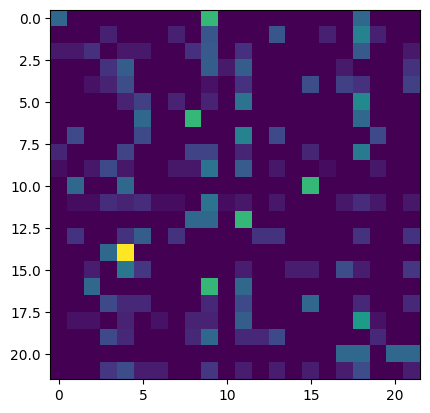

In [60]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')

plt.imshow(conf)

In [61]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.102
